# Regresión lineal con scikit-learn

En este notebook vamos a construir un ejemplo completo y didáctico de **regresión lineal** usando `scikit-learn`. La idea es entender el flujo típico de machine learning, no solo correr el modelo.

## Objetivos
- Entender cuándo usar regresión lineal.
- Crear un dataset con lógica de negocio.
- Entrenar un modelo con `sklearn`.
- Interpretar coeficientes, métricas y predicciones.
- Comparar resultados y detectar limitaciones del modelo.

## 1. ¿Qué problema vamos a resolver?

Supongamos que queremos **predecir el precio de una vivienda** a partir de variables simples como:

- área en metros cuadrados
- número de habitaciones
- antigüedad del inmueble
- distancia al centro de la ciudad

Este es un caso clásico de regresión porque el target es un **valor numérico continuo**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(42)

## 2. Crear un dataset sintético con lógica razonable

Vamos a construir un dataset donde el precio dependa de reglas intuitivas:

- más metros cuadrados → mayor precio
- más habitaciones → mayor precio
- mayor antigüedad → menor precio
- mayor distancia al centro → menor precio

Además agregamos ruido, porque en la vida real nunca observamos relaciones perfectas.

In [2]:
n = 1200

area_m2 = rng.normal(85, 25, size=n).clip(35, 220)
habitaciones = rng.integers(1, 6, size=n)
antiguedad = rng.integers(0, 40, size=n)
dist_centro_km = rng.normal(7, 4, size=n).clip(0.5, 25)

# Regla base de negocio para construir el precio
precio = (
    1800 * area_m2
    + 18000 * habitaciones
    - 2200 * antiguedad
    - 3500 * dist_centro_km
    + rng.normal(0, 25000, size=n)
)
precio = precio.clip(50000, None)

df = pd.DataFrame({
    'area_m2': area_m2,
    'habitaciones': habitaciones,
    'antiguedad': antiguedad,
    'dist_centro_km': dist_centro_km,
    'precio': precio
})

df.head()

,area_m2,habitaciones,antiguedad,dist_centro_km,precio
0,92.617927,3,23,0.564773,142544.368476
1,59.000397,2,0,9.674221,113421.113748
2,103.761280,1,25,11.492379,89555.543428
3,108.514118,3,17,6.820019,174380.227123
4,36.224120,3,14,0.500000,85413.658814


## 3. Exploración rápida

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area_m2,1200.0,84.669994,24.101161,35.0,67.945992,85.086310,100.385936,164.471342
habitaciones,1200.0,3.015833,1.417953,1.0,2.000000,3.000000,4.000000,5.000000
antiguedad,1200.0,19.008333,11.658467,0.0,9.000000,19.000000,29.000000,39.000000
dist_centro_km,1200.0,7.197686,3.822758,0.5,4.390134,7.088972,9.928349,19.354049
precio,1200.0,141473.267540,57402.743901,50000.0,99792.671852,141171.560195,181642.750477,337345.134081


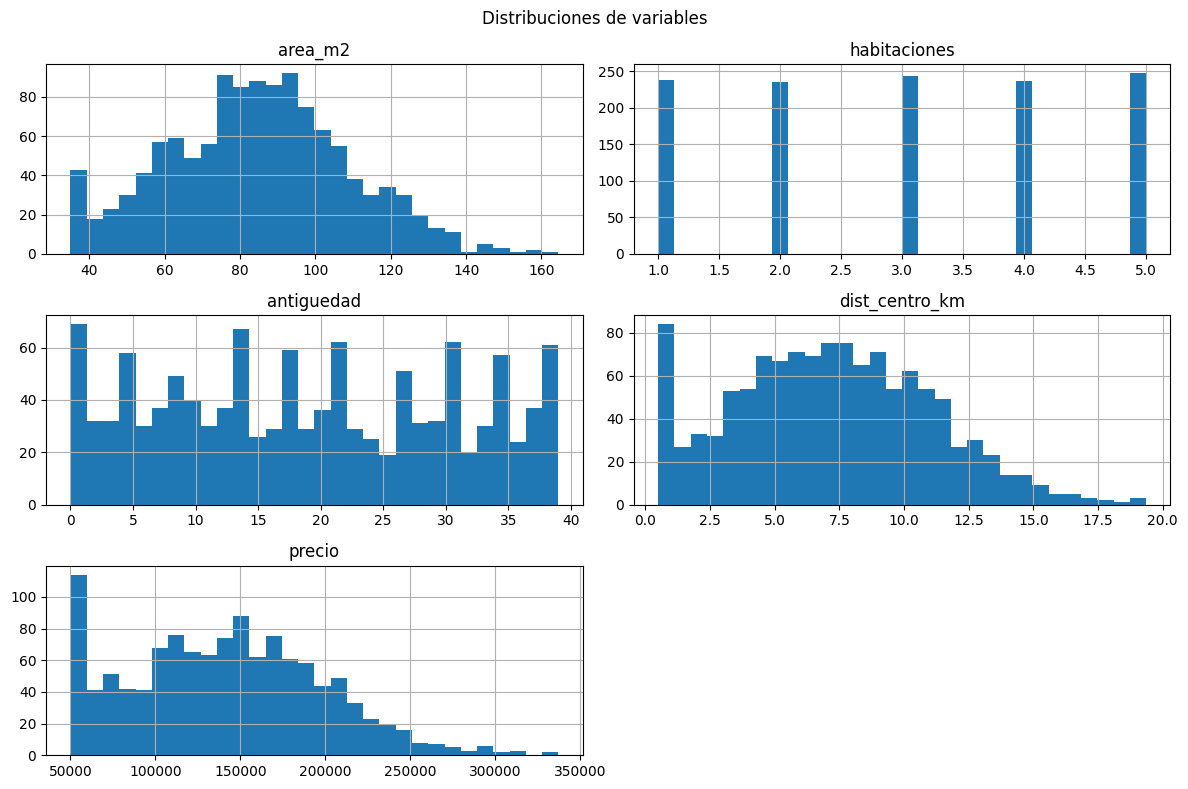

In [4]:
df[['area_m2', 'habitaciones', 'antiguedad', 'dist_centro_km', 'precio']].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones de variables')
plt.tight_layout()
plt.show()

In [5]:
df.corr(numeric_only=True)

,area_m2,habitaciones,antiguedad,dist_centro_km,precio
area_m2,1.000000,-0.048341,-0.016409,0.033729,0.665800
habitaciones,-0.048341,1.000000,0.036116,0.030308,0.363504
antiguedad,-0.016409,0.036116,1.000000,-0.005302,-0.416468
dist_centro_km,0.033729,0.030308,-0.005302,1.000000,-0.173477
precio,0.665800,0.363504,-0.416468,-0.173477,1.000000


## 4. Separar variables predictoras y target

En machine learning solemos llamar:

- `X` a las variables de entrada
- `y` a la variable objetivo

In [6]:
X = df[['area_m2', 'habitaciones', 'antiguedad', 'dist_centro_km']]
y = df['precio']

X.head()

,area_m2,habitaciones,antiguedad,dist_centro_km
0,92.617927,3,23,0.564773
1,59.000397,2,0,9.674221
2,103.761280,1,25,11.492379
3,108.514118,3,17,6.820019
4,36.224120,3,14,0.500000


## 5. Dividir en entrenamiento y prueba

Esto es clave. El modelo debe aprender en una parte de los datos y evaluarse en otra que no vio antes.

- `train`: para entrenar
- `test`: para medir desempeño fuera de muestra

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((900, 4), (300, 4))

## 6. Entrenar el modelo de regresión lineal

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Modelo entrenado')

Modelo entrenado


## 7. Revisar coeficientes

Los coeficientes nos dicen cómo cambia la predicción cuando cambia una variable, manteniendo las demás constantes.

In [9]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': model.coef_
}).sort_values('coeficiente', ascending=False)

coef_df

,feature,coeficiente
1,habitaciones,16702.719277
0,area_m2,1641.050113
2,antiguedad,-2107.556247
3,dist_centro_km,-3190.438200


In [10]:
print('Intercepto:', model.intercept_)

Intercepto: 16172.005713386796


### Cómo interpretar estos coeficientes

Por ejemplo, si el coeficiente de `area_m2` es positivo, significa que **más área se asocia con mayor precio**.

Si el coeficiente de `antiguedad` es negativo, significa que **viviendas más antiguas tienden a valer menos**, todo lo demás constante.

## 8. Hacer predicciones

In [11]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

pred_df = pd.DataFrame({
    'precio_real': y_test.values,
    'precio_predicho': y_pred_test
})
pred_df.head(10)

,precio_real,precio_predicho
0,92383.354312,69448.002220
1,116750.548278,125684.335987
2,210780.877045,198676.883949
3,101464.341790,129025.856055
4,99617.002313,111852.159043
5,168256.178532,157542.313044
6,187859.548545,221695.499726
7,72599.894187,65314.020414
8,50000.000000,5930.589754
9,116510.797020,171866.587694


## 9. Evaluar el modelo

Vamos a usar cuatro métricas comunes:

- **MAE**: error absoluto medio
- **MSE**: error cuadrático medio
- **RMSE**: raíz del MSE
- **R²**: proporción de variabilidad explicada

In [15]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

In [14]:
mae

19305.253778727743

In [16]:
mse

584998676.81312

In [17]:
rmse

584998676.81312

In [18]:
r2

0.8241186089485705

### ¿Cómo leer estas métricas?

- Un **MAE** menor significa que, en promedio, nos equivocamos menos en valor absoluto.
- **RMSE** castiga más los errores grandes.
- **R²** cerca de 1 indica que el modelo explica una buena parte de la variabilidad del target.

Ninguna métrica debe interpretarse sola: siempre hay que leerla en el contexto del negocio.

## 10. Gráfico: valor real vs predicción

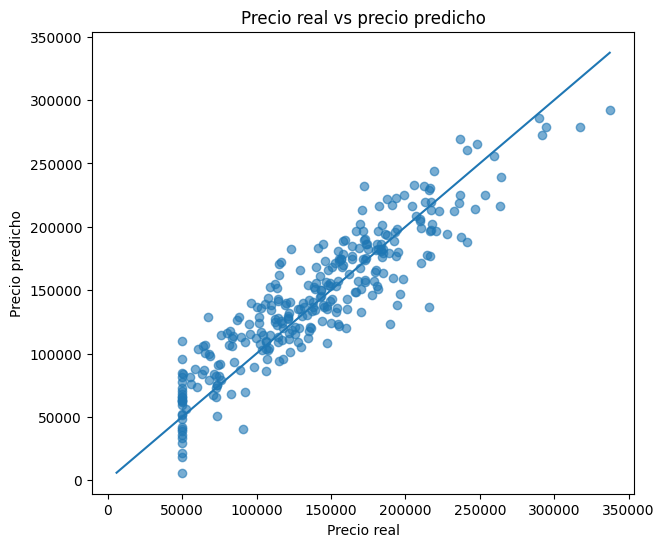

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
line_min = min(y_test.min(), y_pred_test.min())
line_max = max(y_test.max(), y_pred_test.max())
plt.plot([line_min, line_max], [line_min, line_max])
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Precio real vs precio predicho')
plt.show()

Si muchos puntos caen cerca de la diagonal, el modelo está prediciendo razonablemente bien.

## 11. Revisar residuales

El residual es:

\[
residual = y_{real} - y_{predicho}
\]

Analizar residuales ayuda a detectar sesgos, outliers o patrones no capturados por el modelo.

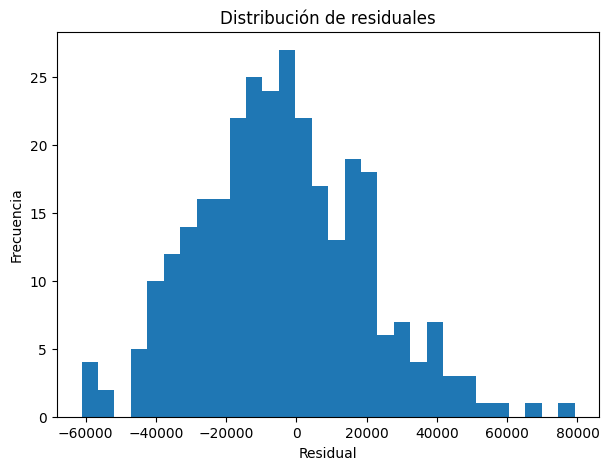

In [20]:
residuals = y_test - y_pred_test

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30)
plt.title('Distribución de residuales')
plt.xlabel('Residual')
plt.ylabel('Frecuencia')
plt.show()

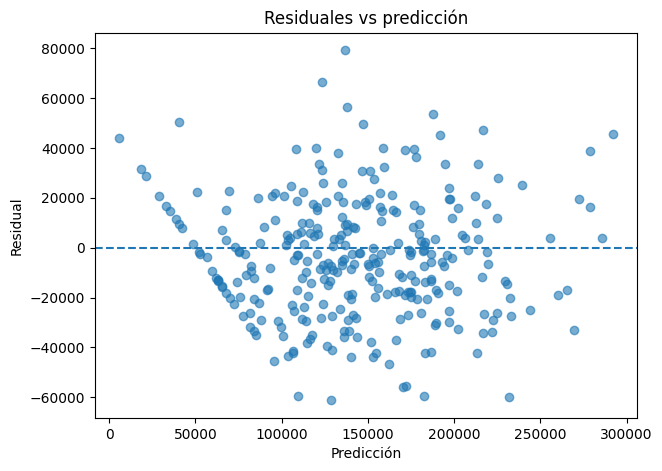

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residual')
plt.title('Residuales vs predicción')
plt.show()

## 12. Hacer predicciones sobre casos nuevos

In [22]:
nuevas_viviendas = pd.DataFrame({
    'area_m2': [60, 95, 140],
    'habitaciones': [2, 3, 4],
    'antiguedad': [15, 8, 3],
    'dist_centro_km': [10, 6, 4]
})

nuevas_viviendas['precio_estimado'] = model.predict(nuevas_viviendas)
nuevas_viviendas

,area_m2,habitaciones,antiguedad,dist_centro_km,precio_estimado
0,60,2,15,10,84522.725319
1,95,3,8,6,186176.845070
2,140,4,3,4,293645.477054


## 13. Fortalezas y limitaciones de la regresión lineal

### Fortalezas
- Fácil de entender e interpretar
- Rápida de entrenar
- Muy buena como baseline

### Limitaciones
- Supone relación lineal
- Puede sufrir con outliers
- Puede quedarse corta si el problema es muy no lineal

## 14. Conclusiones

En este notebook vimos un flujo completo:

1. construir datos
2. separar train/test
3. entrenar con `LinearRegression`
4. evaluar con métricas
5. interpretar coeficientes y errores

La regresión lineal es una excelente primera herramienta para problemas donde el target es numérico y buscamos una solución simple, interpretable y rápida.